In [ ]:
import os, pydicom


folder = r"D:\dicom\manifest-7qRRRBGo6029235898952856192\LungCT-Diagnosis\R_006\09-24-1998-NA-Diagnostic Pre-Surgery Contrast Enhanced CT-41946\2.000000- NONE -71225"

files = [f for f in os.listdir(folder) if f.endswith('.dcm')]
ds    = pydicom.dcmread(os.path.join(folder, files[0]))

print("Modality    :", ds.Modality)
print("PixelSpacing:", ds.PixelSpacing)
print("SliceThick  :", ds.SliceThickness)
print("Num files   :", len(files))
print("HU range    :", ds.pixel_array.min(), "to", ds.pixel_array.max())

Modality    : CT
PixelSpacing: [0.6640625, 0.6640625]
SliceThick  : 3
Num files   : 130
HU range    : 0 to 4095


In [2]:
import os
import pydicom

folder = r"manifest-7qRRRBGo6029235898952856192\LungCT-Diagnosis\R_006"

dicom_files = []

for root, dirs, files in os.walk(folder):
    for f in files:
        if f.lower().endswith(".dcm"):
            dicom_files.append(os.path.join(root, f))

print("Found", len(dicom_files), "DICOM files")

ds = pydicom.dcmread(dicom_files[0])

print("Modality:", ds.Modality)

Found 130 DICOM files
Modality: CT


CT slices: 130
Shape    : (130, 512, 512)
HU range : -1024.0 to 3071.0
Downsampled: (130, 256, 256)
Spacing (mm): [3.0, 0.6640625, 0.6640625]


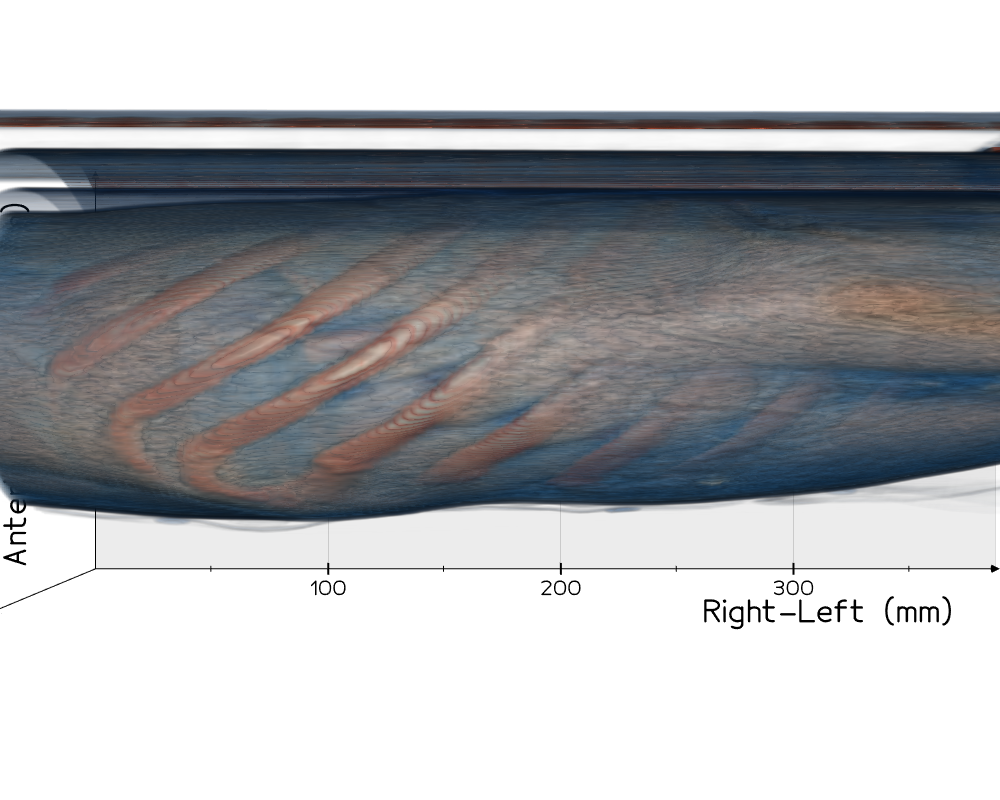

In [ ]:
import pydicom
import numpy as np
import os
from vedo import Volume, show, Axes
from skimage.transform import resize


folder = r"D:\dicom\manifest-7qRRRBGo6029235898952856192\LungCT-Diagnosis\R_006\09-24-1998-NA-Diagnostic Pre-Surgery Contrast Enhanced CT-41946\2.000000- NONE -71225"   # paste your path here

# ── Load all CT slices ───────────────────────────────────────────
files  = sorted([f for f in os.listdir(folder) if f.endswith('.dcm')])
slices = [pydicom.dcmread(os.path.join(folder, f)) for f in files]
slices = [s for s in slices if getattr(s, 'Modality', '') == 'CT']
print(f"CT slices: {len(slices)}")


slices.sort(key=lambda s: float(
    getattr(s, 'ImagePositionPatient', [0, 0, 0])[2]
))


def to_hu(slices):
    vol = []
    for s in slices:
        img       = s.pixel_array.astype(np.float32)
        slope     = float(getattr(s, 'RescaleSlope',     1))
        intercept = float(getattr(s, 'RescaleIntercept', 0))
        vol.append(img * slope + intercept)
    return np.array(vol)

volume = to_hu(slices)
print("Shape    :", volume.shape)
print("HU range :", volume.min(), "to", volume.max())

# ── Downsample to 256x256 ────────────────────────────────────────
volume = resize(volume, (volume.shape[0], 256, 256),
                anti_aliasing=True,
                preserve_range=True).astype(np.float32)
print("Downsampled:", volume.shape)


ps      = slices[0].PixelSpacing        
st      = float(slices[0].SliceThickness)  
spacing = [st, float(ps[0]), float(ps[1])]
print("Spacing (mm):", spacing)

vol = Volume(volume, spacing=spacing)


vol.color([
    (-1024, (0.00, 0.00, 0.00)),   
    ( -900, (0.00, 0.00, 0.00)),   
    ( -500, (0.10, 0.40, 0.80)),   
    ( -100, (0.20, 0.55, 0.85)),   
    (    0, (0.85, 0.85, 0.75)),   
    (  150, (0.90, 0.25, 0.10)),   
    (  400, (0.90, 0.85, 0.70)),   
    ( 1000, (1.00, 1.00, 1.00)),   
])


vol.alpha([
    (-1024, 0.00),
    ( -900, 0.00),
    ( -500, 0.08),   
    ( -100, 0.10),
    (    0, 0.20),
    (  150, 0.75),   
    (  400, 0.88),
    ( 1000, 1.00),
])


axes = Axes(vol,
            xtitle='Right-Left (mm)',
            ytitle='Anterior-Posterior (mm)',
            ztitle='Superior-Inferior (mm)',
            c='black')


from vedo import Volume, show, Axes

cam = dict(
    pos=(0, -600, 0),        
    focalPoint=(0, 0, 0),   
    viewup=(0, 0, 1),        
)

show(vol, axes,
     bg='white',
     title='TB Lung 3D Reconstruction',
     camera=cam,
     size=(1000, 800))